In [1]:
#installs

!pip install pydantic langchain langgraph dotenv langchain-community langchain-openai langchain-text-splitters pypdf faiss-cpu


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [2]:
from typing import List, TypedDict, Literal
from pydantic import BaseModel
import re

from langchain_community.document_loaders import PyPDFLoader
from langchain_community.vectorstores import FAISS
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate


from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv

from langchain_community.tools.tavily_search import TavilySearchResults

load_dotenv()


/var/folders/ld/ycp905357f1f2nfsh734fvl40000gn/T/ipykernel_27644/2199578753.py:5: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyPDFLoader


True

In [3]:
docs = (
    PyPDFLoader("./documents/DDIA.pdf").load()
)

In [4]:
chunks = RecursiveCharacterTextSplitter(chunk_size=900, chunk_overlap=150).split_documents(docs)
for d in chunks:
    d.page_content = d.page_content.encode("utf-8", "ignore").decode()

In [5]:
len(chunks)

2074

In [6]:
embeddings = OpenAIEmbeddings(
    model="text-embedding-bge-m3",
    base_url="http://127.0.0.1:1234/v1",
    api_key="lm-studio",
    check_embedding_ctx_length=False   
)
vector_store = FAISS.from_documents(chunks, embeddings)
retriver = vector_store.as_retriever(search_type="similarity", search_kwargs={"k": 4})

In [7]:
llm = ChatOpenAI(
    model="meta-llama-3.1-8b-instruct",
    base_url="http://127.0.0.1:1234/v1",
    api_key="lm-studio",
    temperature=0
)

In [8]:
UPPER_TH = 0.7
LOWER_TH = 0.3

In [9]:
class State(TypedDict):
    question: str

    docs: List[Document]
    good_docs: List[Document]

    verdict: str
    reason: str

    strips: List[str]
    kept_strips: List[str]
    redefined_context: str

    web_query: str

    web_doc: List[Document]

    answer: str

In [10]:
def retrieve_node(state: State) -> State:
    question = state["question"]
    docs = retriver.invoke(question)
    state["docs"] = docs
    return state

In [12]:
class DocEvalScore(BaseModel):
    score: float
    reason: str

doc_eval_prompt = ChatPromptTemplate.from_messages([
    ("system", "You are a strict retrieval evaluator for RAG.\n"
            "You will be given ONE retrieved chunk and a question.\n"
            "Return a relevance score in [0.0, 1.0].\n"
            "- 1.0: chunk alone is sufficient to answer fully/mostly\n"
            "- 0.0: chunk is irrelevant\n"
            "Be conservative with high scores.\n"
            "Also return a short reason.\n"
            "Output JSON only."),
            ("human", "Question: {question}\n\nChunk:\n{chunk}")
])

doc_eval_chain = doc_eval_prompt | llm.with_structured_output(DocEvalScore)

def eval_each_doc_node(state: State) -> State:
    question = state["question"]
    scores: List[float] = []
    good_docs: List[Document] = []

    for d in state["docs"]:
        out = doc_eval_chain.invoke({"question": question, "chunk": d.page_content})
        score = float(out["score"] if isinstance(out, dict) else out.score)

        scores.append(score)

        if score > LOWER_TH:
            good_docs.append(d)
    
    if any(s > UPPER_TH for s in scores):
         state["verdict"] = "CORRECT"
         state["reason"] = f"At least one retrieved chunk scored > {UPPER_TH}"
         state["good_docs"] = good_docs
         return state
    elif len(scores) > 0 and all(s < LOWER_TH for s in scores):
        state["good_docs"] = []
        state["verdict"] = "WRONG"
        state["reason"] = f"All retrieved chunks scored < {LOWER_TH}"
        return state
    
    state["good_docs"] = good_docs
    state["verdict"] = "AMBIGUOUS"
    state["reason"] = f"No chunk scored > {UPPER_TH} but not all chunk scored were < {LOWER_TH}"

    return state

In [20]:
def decompose_to_sentences(text: str) -> List[str]:
    text = re.sub(r"\s+", " ", text).strip()
    sentences = re.split(r"(?<=[.!?])\s+", text)
    return [s.strip() for s in sentences if len(s.strip()) > 20]

class KeepOrDrop(BaseModel):
    keep: bool

filter_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a strict relevance filter.\n"
            "Return keep=true only if the sentence directly helps answer the question.\n"
            "Use ONLY the sentence. Output JSON only.",
        ),
        ("human", "Question: {question}\n\nSentence:\n{sentence}"),
    ]
)

filter_chain = filter_prompt | llm.with_structured_output(KeepOrDrop)

def refine(state: State) -> State:
    q = state["question"]

    if state.get("verdict") == "CORRECT":
        docs_to_use = state["good_docs"]
    elif state.get("verdict") == "INCORRECT":
        docs_to_use = state["web_doc"]
    else:
        docs_to_use = state["good_docs"] + state["web_doc"]

    context = "\n\n".join(d.page_content for d in docs_to_use).strip()

    strips = decompose_to_sentences(context)

    kept: List[str] = []
    for s in strips:
        out = filter_chain.invoke({"question": q, "sentence": s})
        keep = out["keep"] if isinstance(out, dict) else out.keep
        if keep:
            kept.append(s)

    refiened_context = "\n".join(kept).strip()

    state["strips"] = strips
    state["kept_strips"] = kept
    state["redefined_context"] = refiened_context

    return state


In [28]:
import os

class WebQuery(BaseModel):
    query: str

rewrite_prompt = ChatPromptTemplate.from_messages(
    [
         (
            "system",
            "Rewrite the user question into a web search query composed of keywords.\n"
            "Rules:\n"
            "- Keep it short (6–14 words).\n"
            "- If the question implies recency (e.g., recent/latest/last week/last month), add a constraint like (last 30 days).\n"
            "- Do NOT answer the question.\n"
            "- Return JSON with a single key: query",
        ),
        ("human", "Question: {question}"),
    ]
)

rewrite_chain = rewrite_prompt | llm.with_structured_output(WebQuery)

def rewrite_query_node(state: State) -> State:
    q = state["question"]
    out = rewrite_chain.invoke({"question": q})
    state["web_query"] = out["query"] if isinstance(out, dict) else out.query
    return state


tavily = TavilySearchResults(max_results=4, api_key=os.getenv("TAVILY_API_KEY"))

def web_search_node(state: State) -> State:
    q = state.get("web_query") or state["question"]
    results = tavily.invoke({ "query": q })

    web_docs: List[Document] = []
    for r in results:
        title = r.get("title", "")
        url = r.get("url", "")
        content = r.get("content", "") or r.get("snippet", "")
        text = f"TITLE: {title}\nURL: {url}\nCONTENT: {content}"
        web_docs.append(Document(page_content=text, metadata={"url": url, "title": title}))

    state["web_doc"] = web_docs
    return state

In [29]:
answer_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a helpful ML tutor. Answer ONLY using the provided context.\n"
            "If the context is empty or insufficient, say: 'I don't know.'",
        ),
        ("human", "Question: {question}\n\nContext:\n{context}"),
    ]
)

def generate(state: State) -> State:
    out = (answer_prompt | llm).invoke({"question": state["question"], "context": state["redefined_context"]})
    state["answer"] = str(out)
    return state

In [30]:
def route_after_eval(state: State) -> str:
    if state["verdict"] == "CORRECT":
        return "refine"
    else:
        return "rewrite_query"

In [31]:
g = StateGraph(State)

g.add_node("retrieve", retrieve_node)
g.add_node("eval_each_doc", eval_each_doc_node)

g.add_node("rewrite_query", rewrite_query_node)
g.add_node("web_search", web_search_node)

g.add_node("refine", refine)
g.add_node("generate", generate)

g.add_edge(START, "retrieve")
g.add_edge("retrieve", "eval_each_doc")

g.add_conditional_edges("eval_each_doc", route_after_eval, { "refine": "refine", "rewrite_query": "rewrite_query" })

g.add_edge("rewrite_query", "web_search")
g.add_edge("web_search", "refine")

g.add_edge("refine", "generate")
g.add_edge("generate", END)

app = g.compile()

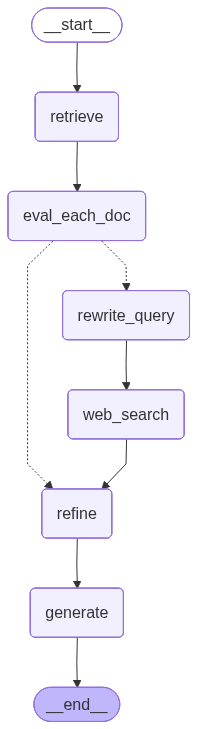

In [32]:
app

In [33]:
res = app.invoke({
    "question": "What are the eval for Rag Pipeline?",
    "docs": [],
    "good_docs": [],
    "verdict": "",
    "reason": "",
    "strips": [],
    "kept_strips": [],
    "redefined_context": "",
    "web_query": "",
    "web_doc": [],
    "answer": ""
})

print("VERDICT:", res["verdict"])
print("REASON:", res["reason"])
print("WEB_QUERY:", res["web_query"])
print("\nOUTPUT:\n", res["answer"])

VERDICT: AMBIGUOUS
REASON: No chunk scored > 0.7 but not all chunk scored were < 0.3
WEB_QUERY: Rag pipeline evaluation metrics

OUTPUT:
 content='The eval for Rag Pipeline involves 5 key industry-standard metrics, which can be applied to evaluate RAG pipelines from an end-to-end perspective or at a component-level. However, based on the provided code snippet (`rag_pipeline/evaluator.py`), it seems that the `RAGASEvaluator` class uses the following RAG-specific diagnostics and metrics:\n\n1. Faithfulness\n2. FactualCorrectness\n3. LLMContextRecall\n\nThese metrics are used to evaluate the quality of a RAG pipeline\'s "retriever" and the "generator" separately, as well as the end-to-end performance of the pipeline.' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 131, 'prompt_tokens': 673, 'total_tokens': 804, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': None, 'reasoning_tokens': 0, 'rejected_prediction_tok

In [34]:
print(res["web_doc"])

[Document(metadata={'url': 'https://www.confident-ai.com/blog/rag-evaluation-metrics-answer-relevancy-faithfulness-and-more', 'title': 'RAG Evaluation Metrics: Assessing Answer Relevancy, Faithfulness ...'}, page_content="TITLE: RAG Evaluation Metrics: Assessing Answer Relevancy, Faithfulness ...\nURL: https://www.confident-ai.com/blog/rag-evaluation-metrics-answer-relevancy-faithfulness-and-more\nCONTENT: ## TL;DR\n\n## What is RAG Evaluation?\n\nRAG evaluation is the process of using metrics such as answer relevancy, faithfulness, and contextual relevancy to test the quality of a RAG pipeline’s “retriever” and the “generator” separately to measure each component’s contribution to the final response quality\n\nTo do this, RAG evaluation involves 5 key industry-standard metrics:\n\nFor agentic RAG use cases, which we'll cover more in a later section, you might also find it useful to include a task completion metric to evaluate your AI agent RAG pipeline as well. [...] And that’s it! Fu